# 🧩 Multi-Agent Research System (LangGraph)

**Agents:** Planner → Research → Writer → Formatter → Verifier (loops back on failure)

**Tools:** `web_search` (DuckDuckGo), `scrape_url` (requests + BeautifulSoup), `retrieve_context` (RAG / FAISS), `to_markdown_report`, `word_count`

**LLM:** `gpt-4o-mini` via OpenAI (cheapest OpenAI model — an OpenAI API key with a small balance is still required; it is *not* literally free). A fully free drop-in alternative using Groq's free-tier Llama models is included as a commented block if you don't want to use OpenAI at all.

**RAG embeddings:** `sentence-transformers/all-MiniLM-L6-v2` (runs locally, no API key, genuinely free).

---

## Architecture Diagram (Mermaid)

```mermaid
flowchart TD
    START([Start]) --> PLANNER["🧭 Planner Agent"]
    PLANNER --> RESEARCH["🔎 Research Agent<br/>web_search + scrape_url + RAG index"]
    RESEARCH --> WRITER["✍️ Writer Agent"]
    WRITER --> FORMATTER["🧹 Formatter Agent<br/>to_markdown_report"]
    FORMATTER --> VERIFIER{"✅ Verifier Agent<br/>enough info? formatted OK?"}
    VERIFIER -- "verified OR max_iterations reached" --> ENDN([End])
    VERIFIER -- "redo_stage = research" --> RESEARCH
    VERIFIER -- "redo_stage = writer" --> WRITER
    VERIFIER -- "redo_stage = formatter" --> FORMATTER
```

This exact graph is also generated programmatically from the compiled LangGraph app near the bottom of this notebook, so the diagram always matches the real code.


## 1. Install dependencies (Colab)

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-community langchain-huggingface \
    langchain-core sentence-transformers faiss-cpu beautifulsoup4 requests ddgs tiktoken


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.0/567.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.

## 2. Imports

In [2]:
import os, re, json
from typing import TypedDict, List

import requests
from bs4 import BeautifulSoup

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph import StateGraph, END

# duckduckgo-search was renamed to `ddgs`; support either package name
try:
    from ddgs import DDGS
except ImportError:
    from duckduckgo_search import DDGS


/tmp/ipykernel_2299/3307939704.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


## 3. LLM setup

You will be prompted for an **OpenAI API key**. `gpt-4o-mini` is the cheapest OpenAI chat model — cents per run, but not literally $0.

If you want a **genuinely free** option instead, skip the key prompt, uncomment the Groq block below, and get a free key from https://console.groq.com.

In [3]:
import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# ---- FULLY FREE ALTERNATIVE (no OpenAI cost) ----
# !pip install -q langchain-groq
# from langchain_groq import ChatGroq
# os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")
# llm = ChatGroq(model="llama-3.1-70b-versatile", temperature=0.3)


Enter your OpenAI API key: ··········


## 4. RAG index (local, free embeddings)

In [4]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = None  # a FAISS index, built lazily as the research agent scrapes pages

def add_documents_to_index(chunks: List[dict]):
    """chunks: [{'text': str, 'source': str}, ...]"""
    global vector_store
    docs = [Document(page_content=c["text"], metadata={"source": c["source"]}) for c in chunks if c.get("text")]
    if not docs:
        return
    if vector_store is None:
        vector_store = FAISS.from_documents(docs, embeddings)
    else:
        vector_store.add_documents(docs)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 5. Tools — web search, scraper, RAG retrieval, formatting helpers

In [5]:
@tool
def web_search(query: str, max_results: int = 4) -> List[dict]:
    """Search the web via DuckDuckGo. Returns a list of {title, href, body} dicts."""
    try:
        with DDGS() as ddgs:
            return list(ddgs.text(query, max_results=max_results))
    except Exception as e:
        return [{"title": "search_error", "href": "", "body": str(e)}]


@tool
def scrape_url(url: str, max_chars: int = 2500) -> str:
    """Fetch a URL and return cleaned visible text, truncated to max_chars."""
    try:
        headers = {"User-Agent": "Mozilla/5.0 (research-bot)"}
        resp = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(resp.text, "html.parser")
        for tag in soup(["script", "style", "nav", "footer", "header", "form"]):
            tag.decompose()
        text = " ".join(soup.get_text(separator=" ").split())
        return text[:max_chars]
    except Exception as e:
        return f"[scrape_error] {e}"


@tool
def retrieve_context(query: str, k: int = 6) -> str:
    """Retrieve the most relevant chunks from the RAG index for a query."""
    if vector_store is None:
        return ""
    docs = vector_store.similarity_search(query, k=k)
    return "\n\n".join(f"[Source: {d.metadata.get('source', '?')}]\n{d.page_content}" for d in docs)


@tool
def to_markdown_report(title: str, body: str, sources: List[str]) -> str:
    """Wrap body text into a structured markdown report with a title and a Sources section."""
    uniq_sources = sorted(set(s for s in sources if s))
    src_block = "\n".join(f"- {s}" for s in uniq_sources) if uniq_sources else "- (no sources captured)"
    return f"# {title}\n\n{body}\n\n## Sources\n{src_block}"


@tool
def word_count(text: str) -> int:
    """Return the number of words in the given text."""
    return len(text.split())


## 6. Shared graph state

In [6]:
class AgentState(TypedDict):
    query: str
    plan: str
    search_queries: List[str]
    research_notes: str
    sources: List[str]
    draft: str
    formatted_content: str
    verified: bool
    feedback: str
    redo_stage: str   # 'research' | 'writer' | 'formatter' | 'none'
    iteration: int
    max_iterations: int


## 7. Agent nodes

In [7]:
def planner_agent(state: AgentState) -> AgentState:
    feedback_note = f"\nPrevious verifier feedback to address: {state.get('feedback', '')}" if state.get("feedback") else ""
    prompt = f"""You are a research planning agent.
Break the user's request into a short, concrete research plan.

User request: {state['query']}{feedback_note}

Return EXACTLY in this format:
PLAN: <one paragraph describing what the final answer must cover>
QUERIES:
- <search query 1>
- <search query 2>
- <search query 3>
"""
    response = llm.invoke([HumanMessage(content=prompt)]).content
    plan_match = re.search(r"PLAN:(.*?)QUERIES:", response, re.S)
    plan_text = plan_match.group(1).strip() if plan_match else response.strip()
    tail = response.split("QUERIES:")[-1] if "QUERIES:" in response else ""
    queries = [q.strip() for q in re.findall(r"-\s*(.+)", tail) if q.strip()][:5]
    if not queries:
        queries = [state["query"]]
    return {**state, "plan": plan_text, "search_queries": queries}


def research_agent(state: AgentState) -> AgentState:
    notes = []
    sources = list(state.get("sources", []))
    for q in state["search_queries"]:
        results = web_search.invoke({"query": q, "max_results": 4})
        for r in results[:3]:
            url = r.get("href", "")
            if not url:
                continue
            scraped = scrape_url.invoke({"url": url, "max_chars": 2500})
            if scraped and not scraped.startswith("[scrape_error]"):
                add_documents_to_index([{"text": scraped, "source": url}])
                notes.append(f"Query: {q}\nSource: {url}\nSnippet: {r.get('body', '')}")
                sources.append(url)
    retrieved = retrieve_context.invoke({"query": state["query"], "k": 6})
    combined = "\n\n---\n\n".join(notes) + "\n\n=== RAG CONTEXT ===\n" + retrieved
    return {**state, "research_notes": combined, "sources": sources}


def writer_agent(state: AgentState) -> AgentState:
    feedback_note = ""
    if state.get("feedback") and state.get("redo_stage") == "writer":
        feedback_note = f"\nAddress this verifier feedback: {state['feedback']}"
    prompt = f"""You are a writing agent. Using the plan and research notes below, write a clear,
well-structured, factual answer to the user's query. Cover every point in the plan.

User query: {state['query']}
Plan: {state['plan']}

Research notes:
{state['research_notes'][:6000]}
{feedback_note}

Write the full draft now.
"""
    draft = llm.invoke([HumanMessage(content=prompt)]).content
    return {**state, "draft": draft}


def formatter_agent(state: AgentState) -> AgentState:
    feedback_note = ""
    if state.get("feedback") and state.get("redo_stage") == "formatter":
        feedback_note = f"\nAddress this formatting feedback: {state['feedback']}"
    prompt = f"""You are a formatting agent. Convert the draft below into a clean, professional
markdown report body. Use clear '##' section headings and bullet points where useful.
Keep all factual content — do not shorten or remove information.
{feedback_note}

Draft:
{state['draft']}
"""
    body = llm.invoke([HumanMessage(content=prompt)]).content
    formatted = to_markdown_report.invoke({"title": state["query"], "body": body, "sources": state["sources"]})
    return {**state, "formatted_content": formatted}


def verifier_agent(state: AgentState) -> AgentState:
    wc = word_count.invoke({"text": state["formatted_content"]})
    prompt = f"""You are a strict verifier agent. Check the FORMATTED CONTENT against the user's
query and plan.

Checks:
1. COVERAGE: does it contain enough substantive information to fully answer the query and follow the plan?
2. FORMATTING: does it have a title, '##' section headings, and a Sources section, with no broken markdown?

Word count: {wc}
User query: {state['query']}
Plan: {state['plan']}

FORMATTED CONTENT:
{state['formatted_content'][:6000]}

Respond with ONLY strict JSON, nothing else:
{{"verified": true or false, "feedback": "short actionable feedback", "redo_stage": "research" or "writer" or "formatter" or "none"}}
"""
    raw = llm.invoke([HumanMessage(content=prompt)]).content
    raw_clean = re.sub(r"```json|```", "", raw).strip()
    try:
        result = json.loads(raw_clean)
    except Exception:
        result = {
            "verified": wc > 150,
            "feedback": "Verifier output could not be parsed; fell back to a word-count heuristic.",
            "redo_stage": "none" if wc > 150 else "research",
        }

    iteration = state["iteration"] + 1
    hit_limit = iteration >= state["max_iterations"]
    verified = bool(result.get("verified", False)) or hit_limit
    return {
        **state,
        "verified": verified,
        "feedback": result.get("feedback", ""),
        "redo_stage": result.get("redo_stage", "none"),
        "iteration": iteration,
    }


## 8. Conditional routing (the verify → redo loop)

In [8]:
def route_after_verifier(state: AgentState) -> str:
    if state["verified"]:
        return "end"
    stage = state.get("redo_stage", "none")
    if stage in ("research", "writer", "formatter"):
        return stage
    return "end"


## 9. Build the LangGraph

In [9]:
graph = StateGraph(AgentState)
graph.add_node("planner", planner_agent)
graph.add_node("research", research_agent)
graph.add_node("writer", writer_agent)
graph.add_node("formatter", formatter_agent)
graph.add_node("verifier", verifier_agent)

graph.set_entry_point("planner")
graph.add_edge("planner", "research")
graph.add_edge("research", "writer")
graph.add_edge("writer", "formatter")
graph.add_edge("formatter", "verifier")
graph.add_conditional_edges(
    "verifier",
    route_after_verifier,
    {"research": "research", "writer": "writer", "formatter": "formatter", "end": END},
)

app = graph.compile()
print("Graph compiled ✅")


Graph compiled ✅


## 10. Auto-generated Mermaid diagram (from the real compiled graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	research(research)
	writer(writer)
	formatter(formatter)
	verifier(verifier)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	formatter --> verifier;
	planner --> research;
	research --> writer;
	verifier -. &nbsp;end&nbsp; .-> __end__;
	verifier -.-> formatter;
	verifier -.-> research;
	verifier -.-> writer;
	writer --> formatter;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



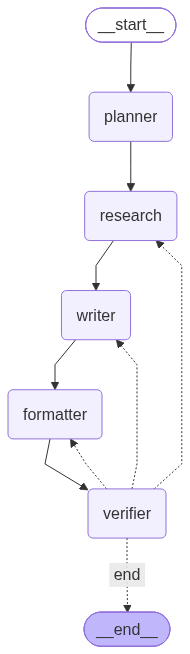

In [10]:
print(app.get_graph().draw_mermaid())

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG render skipped (needs internet access to mermaid.ink):", e)


## 11. Run it

In [12]:
initial_state = {
    "query": "What are the key benefits and risks of Tsunami?",
    "plan": "",
    "search_queries": [],
    "research_notes": "",
    "sources": [],
    "draft": "",
    "formatted_content": "",
    "verified": False,
    "feedback": "",
    "redo_stage": "none",
    "iteration": 0,
    "max_iterations": 3,
}

final_state = app.invoke(initial_state)

print(final_state["formatted_content"])
print(f"\n\n--- verified={final_state['verified']} | iterations used: {final_state['iteration']} ---")


# What are the key benefits and risks of Tsunami?

# Tsunamis: Ecological Benefits and Associated Risks

Tsunamis, while primarily known for their destructive power, can also have certain ecological benefits. Understanding both the advantages and risks associated with tsunamis is crucial for communities living in vulnerable coastal areas.

## Key Benefits of Tsunamis

- **Ecosystem Rejuvenation**: 
  - Tsunamis can play a role in rejuvenating coastal ecosystems.
  - They redistribute nutrients in ocean waters and on land, promoting growth in various ecosystems.
  - This nutrient redistribution can enhance the productivity of marine life and support the recovery of damaged habitats.

- **Creation of New Habitats**: 
  - The force of a tsunami can create temporary ponds and other habitats that may benefit certain species.
  - These newly formed environments can provide breeding grounds and increase biodiversity in the affected areas.

- **Natural Shock Absorption**: 
  - Coastal ecosyste

## Notes
- **Loop cap:** `max_iterations` (default 3) prevents infinite loops even if the verifier never approves.
- **Where the loop can jump back to:** the verifier's `redo_stage` decides whether to redo `research` (not enough info), `writer` (content weak/incomplete), or `formatter` (bad formatting) — not always all the way back to `planner`.
- **Swap in a fully free LLM:** replace the `ChatOpenAI` line with the commented `ChatGroq` block in section 3 to run with zero API cost.
- **Costs:** only the LLM calls (OpenAI or Groq) cost anything; DuckDuckGo search, scraping, and the embedding model are free.
